In [ ]:
# INSTALL + IMPORTS
!pip install -q kaggle albumentations torchmetrics opencv-python

import os
import cv2
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET

from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split

from torch.utils.data import Dataset, DataLoader, Subset

from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights

from torchmetrics.detection.mean_ap import MeanAveragePrecision

import albumentations as A
from albumentations.pytorch import ToTensorV2

%matplotlib inline

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 17.8 MB/s eta 0:00:00


In [ ]:
# DEVICE
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [ ]:
# DOWNLOAD DATASET
from google.colab import drive
drive.mount('/content/drive')

os.environ['KAGGLE_CONFIG_DIR'] = '/content/'

!kaggle datasets download -d andrewmvd/face-mask-detection -p /content/ --unzip

Mounted at /content/drive
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/face-mask-detection
License(s): CC0-1.0
100% 398M/398M [00:02<00:00, 186MB/s]



In [ ]:
# Пути(PATHS)
images_dir = "/content/images"
annotations_dir = "/content/annotations"

print(len(os.listdir(images_dir)))
print(len(os.listdir(annotations_dir)))

853
853


In [ ]:
# XML PARSER (2 CLASSES ONLY)
def parse_xml(xml_path):

    tree = ET.parse(xml_path)
    root = tree.getroot()

    boxes = []
    labels = []

    for obj in root.findall("object"):

        cls = obj.find("name").text

        # ONLY 2 CLASSES

        if cls == "with_mask":
            label = 1

        elif cls == "without_mask":
            label = 2

        else:
            continue


        bbox = obj.find("bndbox")

        xmin = float(bbox.find("xmin").text)
        ymin = float(bbox.find("ymin").text)
        xmax = float(bbox.find("xmax").text)
        ymax = float(bbox.find("ymax").text)

        # INVALID BOX FILTER

        if xmax <= xmin or ymax <= ymin:
            continue

        boxes.append([xmin, ymin, xmax, ymax])
        labels.append(label)

    return boxes, labels

In [ ]:
# TRANSFORMS
def get_train_transform():

    return A.Compose([

        A.LongestMaxSize(max_size=768),

        A.PadIfNeeded(
            min_height=768,
            min_width=768,
            border_mode=cv2.BORDER_CONSTANT
        ),

        A.HorizontalFlip(p=0.5),

        A.RandomBrightnessContrast(p=0.3),

        A.RandomSizedBBoxSafeCrop(
            height=640,
            width=640,
            p=0.3
        ),

        A.Affine(
            scale=(0.9, 1.1),
            rotate=(-10, 10),
            border_mode=cv2.BORDER_CONSTANT,
            p=0.3
        ),

        A.GaussNoise(p=0.1),

        A.Normalize(
            mean=(0,0,0),
            std=(1,1,1)
        ),

        ToTensorV2()

    ],

    bbox_params=A.BboxParams(
        format='pascal_voc',
        label_fields=['labels'],
        min_visibility=0.3,
        clip=True
    ))

In [ ]:
# VALID TRANSFORM
def get_valid_transform():

    return A.Compose([

        A.LongestMaxSize(max_size=768),

        A.PadIfNeeded(
            min_height=768,
            min_width=768,
            border_mode=cv2.BORDER_CONSTANT
        ),

        A.Normalize(
            mean=(0,0,0),
            std=(1,1,1)
        ),

        ToTensorV2()

    ],

    bbox_params=A.BboxParams(
        format='pascal_voc',
        label_fields=['labels'],
        clip=True
    ))

In [ ]:
# DATASET
class FaceMaskDataset(Dataset):

    def __init__(self, image_dir, ann_dir, transforms=None):

        self.image_dir = image_dir
        self.ann_dir = ann_dir
        self.transforms = transforms

        self.images = sorted(os.listdir(image_dir))


    def __len__(self):
        return len(self.images)


    def __getitem__(self, idx):

        image_name = self.images[idx]

        image_path = os.path.join(self.image_dir, image_name)

        ann_path = os.path.join(
            self.ann_dir,
            image_name.replace(".png", ".xml")
        )

        image = np.array(
            Image.open(image_path).convert("RGB")
        )

        boxes, labels = parse_xml(ann_path)

        transformed = self.transforms(
            image=image,
            bboxes=boxes,
            labels=labels
        )

        image = transformed["image"]

        boxes = torch.tensor(
            transformed["bboxes"],
            dtype=torch.float32
        )

        labels = torch.tensor(
            transformed["labels"],
            dtype=torch.int64
        )

        target = {
            "boxes": boxes,
            "labels": labels
        }

        return image, target

In [ ]:
# TRAIN / VAL SPLIT
all_images = sorted(os.listdir(images_dir))

train_ids, val_ids = train_test_split(
    list(range(len(all_images))),
    test_size=0.2,
    random_state=42,
    shuffle=True
)

In [ ]:
# DATASETS
train_dataset = FaceMaskDataset(
    images_dir,
    annotations_dir,
    transforms=get_train_transform()
)

val_dataset = FaceMaskDataset(
    images_dir,
    annotations_dir,
    transforms=get_valid_transform()
)

train_dataset = Subset(train_dataset, train_ids)
val_dataset = Subset(val_dataset, val_ids)

In [ ]:
# DATALOADERS
def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn
)

In [ ]:
# MODEL (NO FREEZE)
def get_model():

    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
        weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT
    )

    in_features = model.roi_heads.box_predictor.cls_score.in_features

    model.roi_heads.box_predictor = FastRCNNPredictor(
        in_features,
        num_classes=3
    )

    return model


model = get_model().to(device)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 186MB/s]


In [ ]:
# RPN + ROI TUNING (ВАЖНО)
# LESS FALSE POSITIVES (FP)

model.rpn.pre_nms_top_n_test = 300
model.rpn.post_nms_top_n_test = 100

model.roi_heads.score_thresh = 0.5
model.roi_heads.nms_thresh = 0.3
model.roi_heads.detections_per_img = 30

In [ ]:
# OPTIMIZER
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [ ]:
# SCHEDULER
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=15
)

In [ ]:
# METRIC
metric = MeanAveragePrecision()

In [ ]:
# TRAINING LOOP
num_epochs = 15

best_map = 0
save_path = "/content/drive/MyDrive/best_fasterrcnn.pth"

for epoch in range(num_epochs):

    model.train()
    epoch_loss = 0

    loop = tqdm(train_loader)

    for images, targets in loop:

        # перенос на устройство

        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]


        # исправление: удалить пустые bounding boxes

        filtered_images = []
        filtered_targets = []

        for img, target in zip(images, targets):

            boxes = target["boxes"]

            # пропустить пустые или повреждённые аннотации
            if boxes is None or len(boxes) == 0:
                continue

            if boxes.ndim != 2 or boxes.shape[1] != 4:
                continue

            filtered_images.append(img)
            filtered_targets.append(target)

        # пропустить батч, если всё удалено
        if len(filtered_images) == 0:
            continue

        images = filtered_images
        targets = filtered_targets


        # forward pass

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        # обратное распространение ошибки (backpropagation)
        optimizer.zero_grad()
        losses.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 10)
        optimizer.step()

        epoch_loss += losses.item()

        loop.set_description(f"Epoch {epoch+1}")
        loop.set_postfix(loss=losses.item())

    scheduler.step()

    print(f"\nEpoch {epoch+1} Loss: {epoch_loss:.4f}")


    # валидация (mAP — средняя точность детекции)

    model.eval()
    metric.reset()

    with torch.no_grad():

        for images, targets in val_loader:

            images = [img.to(device) for img in images]

            outputs = model(images)

            preds = []
            gts = []

            for out in outputs:
                preds.append({
                    "boxes": out["boxes"].cpu(),
                    "scores": out["scores"].cpu(),
                    "labels": out["labels"].cpu()
                })

            for t in targets:
                gts.append({
                    "boxes": t["boxes"],
                    "labels": t["labels"]
                })

            metric.update(preds, gts)

    results = metric.compute()
    map50 = results["map_50"].item()

    print("mAP50:", map50)


    # сохранить лучшую модель

    if map50 > best_map:
        best_map = map50

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "map50": map50
        }, save_path)

        print("BEST MODEL SAVED")

    # ранняя остановка обучения
    if best_map >= 0.85:
        print("TARGET mAP 0.85 REACHED")
        break

Epoch 1: 100%|██████████| 171/171 [02:33<00:00,  1.11it/s, loss=0.0739]


Epoch 1 Loss: 76.4529


mAP50: 0.7139026522636414
BEST MODEL SAVED


Epoch 2: 100%|██████████| 171/171 [02:34<00:00,  1.11it/s, loss=0.312]


Epoch 2 Loss: 57.3927


...


Epoch 6 Loss: 46.7251


mAP50: 0.8457686901092529
BEST MODEL SAVED


Epoch 7: 100%|██████████| 171/171 [02:33<00:00,  1.11it/s, loss=0.376]


Epoch 7 Loss: 42.2777


mAP50: 0.8569909930229187
BEST MODEL SAVED
TARGET mAP 0.85 REACHED


In [ ]:
# LOAD BEST MODEL
checkpoint = torch.load(save_path, map_location=device)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.to(device)

model.eval()

print("BEST mAP50:", checkpoint["map50"])

BEST mAP50: 0.8569909930229187


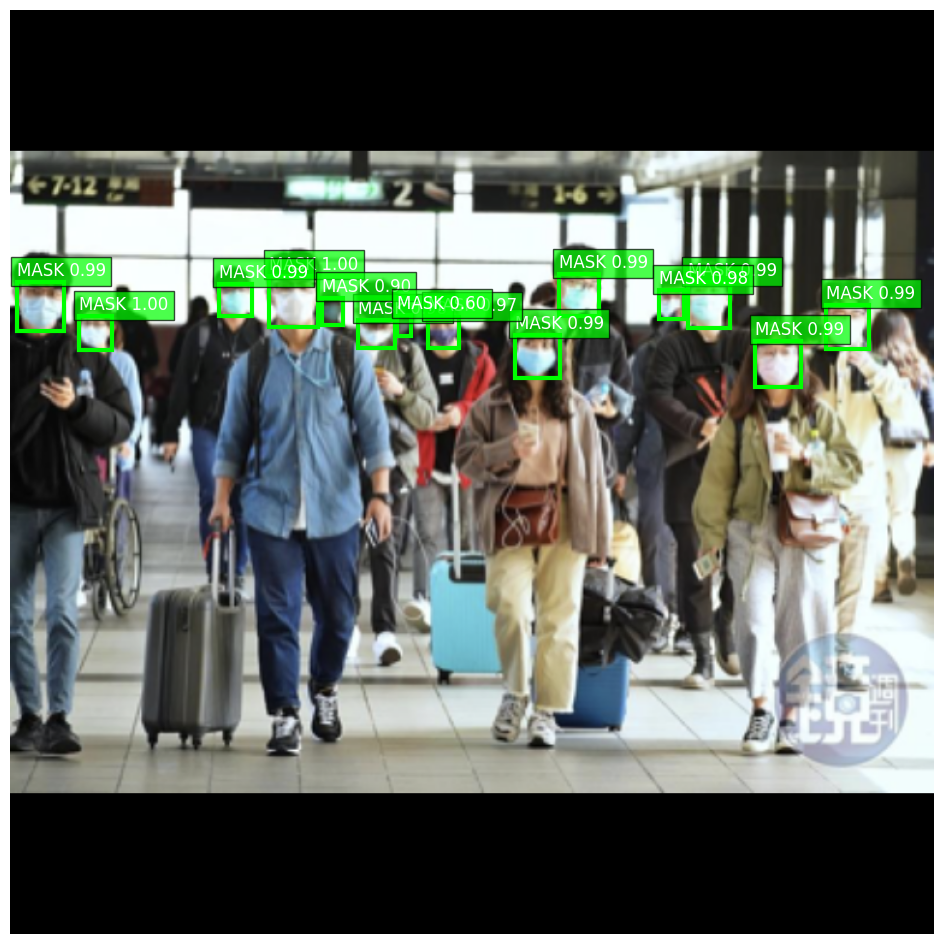

In [ ]:
# FINAL VISUALIZATION
import matplotlib.patches as patches

CLASS_NAMES = {
    1: "MASK",
    2: "NO MASK"
}

COLORS = {
    1: "lime",
    2: "red"
}

images, targets = next(iter(val_loader))

image = images[0].to(device)

model.eval()

with torch.no_grad():

    prediction = model([image])[0]

boxes = prediction["boxes"].cpu().numpy()
scores = prediction["scores"].cpu().numpy()
labels = prediction["labels"].cpu().numpy()

img = image.permute(1,2,0).cpu().numpy()

fig, ax = plt.subplots(1, figsize=(12,12))

ax.imshow(img)

for box, score, label in zip(boxes, scores, labels):

    if score < 0.5:
        continue

    x1, y1, x2, y2 = box

    rect = patches.Rectangle(
        (x1,y1),
        x2-x1,
        y2-y1,
        linewidth=3,
        edgecolor=COLORS[label],
        facecolor='none'
    )

    ax.add_patch(rect)

    ax.text(
        x1,
        y1-5,
        f"{CLASS_NAMES[label]} {score:.2f}",
        color="white",
        fontsize=12,
        bbox=dict(
            facecolor=COLORS[label],
            alpha=0.7
        )
    )

plt.axis("off")

plt.show()

#Далее посмотрим на **ключевые  метрики оценки качества**

- Уже получили  mAP50 > 0.85 (Mean Average Precision @ IoU=0.5)

Главная метрика качества модели детекции.

Она показывает:
- насколько точно модель находит объекты
- насколько правильно классифицирует объекты
- насколько точно локализует bounding boxes
---

##**IoU (Intersection over Union)**

Метрика качества локализации bounding box.

Она показывает, насколько сильно пересекаются:
- предсказанный bbox
- реальный bbox

Если получим **IoU > 0.7 → значит высокая точность локализации**

---

##**Precision–Recall Curve (PR Curve)**

Одна из ключевых визуализаций качества object detection.

Она показывает баланс между:

- Precision → насколько мало ложных срабатываний
- Recall → насколько мало пропущенных объектов

Следует получить **устойчивую PR-кривую**
- detection задачи всегда имеют trade-off
- PR curve показывает поведение модели при разных confidence threshold






In [ ]:
# IoU ANALYSIS
# здесь считаем средний IoU модели на validation.

import numpy as np

def compute_iou(box1, box2):

    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])

    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter = max(0, x2 - x1) * max(0, y2 - y1)

    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])

    union = area1 + area2 - inter + 1e-6

    return inter / union


ious = []

model.eval()

with torch.no_grad():

    for images, targets in val_loader:

        images = [img.to(device) for img in images]

        outputs = model(images)

        for i in range(len(images)):

            pred_boxes = outputs[i]["boxes"].cpu()
            pred_scores = outputs[i]["scores"].cpu()

            gt_boxes = targets[i]["boxes"]

            # confidence filtering
            keep = pred_scores > 0.5

            pred_boxes = pred_boxes[keep]

            for pb in pred_boxes:

                best_iou = 0

                for gb in gt_boxes:

                    iou = compute_iou(pb, gb)

                    if iou > best_iou:
                        best_iou = iou

                ious.append(best_iou)

mean_iou = np.mean(ious)

print("Mean IoU:", round(mean_iou, 4))

Mean IoU: 0.7174


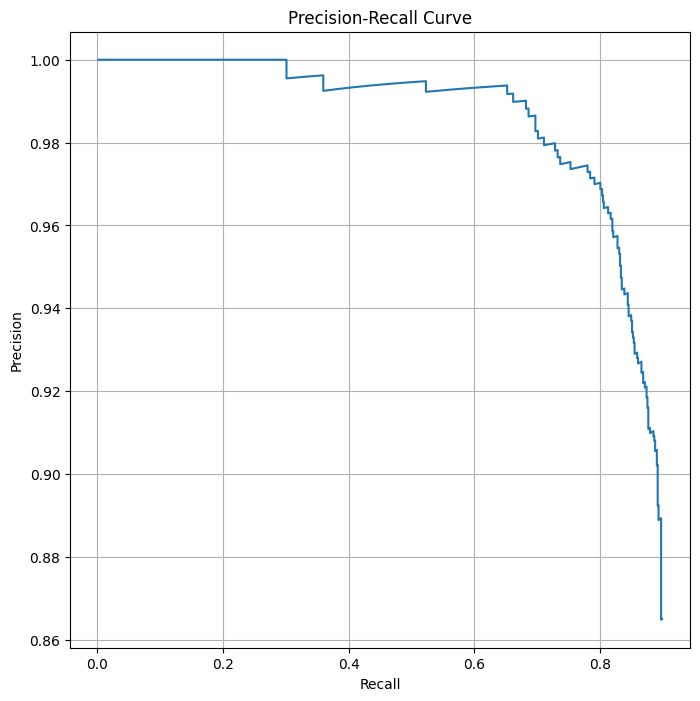

In [ ]:
# PR CURVE

import numpy as np
import matplotlib.pyplot as plt

model.eval()

all_scores = []
all_matches = []

total_gt = 0

iou_threshold = 0.5

with torch.no_grad():

    for images, targets in val_loader:

        images = [img.to(device) for img in images]

        outputs = model(images)

        for i in range(len(images)):

            pred_boxes = outputs[i]["boxes"].cpu()
            pred_scores = outputs[i]["scores"].cpu()
            pred_labels = outputs[i]["labels"].cpu()

            gt_boxes = targets[i]["boxes"].cpu()
            gt_labels = targets[i]["labels"].cpu()

            total_gt += len(gt_boxes)

            # SORT BY CONFIDENCE

            sorted_idx = pred_scores.argsort(descending=True)

            pred_boxes = pred_boxes[sorted_idx]
            pred_scores = pred_scores[sorted_idx]
            pred_labels = pred_labels[sorted_idx]

            matched_gt = set()

            for box, score, label in zip(
                pred_boxes,
                pred_scores,
                pred_labels
            ):

                best_iou = 0
                best_gt_idx = -1

                for j, gt_box in enumerate(gt_boxes):

                    if j in matched_gt:
                        continue

                    # CLASS CHECK

                    if label != gt_labels[j]:
                        continue

                    # IoU

                    x1 = max(box[0], gt_box[0])
                    y1 = max(box[1], gt_box[1])

                    x2 = min(box[2], gt_box[2])
                    y2 = min(box[3], gt_box[3])

                    inter = max(0, x2 - x1) * max(0, y2 - y1)

                    area_pred = (
                        (box[2] - box[0]) *
                        (box[3] - box[1])
                    )

                    area_gt = (
                        (gt_box[2] - gt_box[0]) *
                        (gt_box[3] - gt_box[1])
                    )

                    union = area_pred + area_gt - inter

                    iou = inter / (union + 1e-6)

                    if iou > best_iou:

                        best_iou = iou
                        best_gt_idx = j

                # TRUE POSITIVE / FALSE POSITIVE

                if best_iou >= iou_threshold:

                    all_matches.append(1)

                    matched_gt.add(best_gt_idx)

                else:

                    all_matches.append(0)

                all_scores.append(score.item())

# NUMPY

all_scores = np.array(all_scores)
all_matches = np.array(all_matches)

# GLOBAL SORT

sorted_idx = np.argsort(-all_scores)

all_matches = all_matches[sorted_idx]

# CUMULATIVE TP / FP

tp = np.cumsum(all_matches)

fp = np.cumsum(1 - all_matches)

precision = tp / (tp + fp + 1e-6)

recall = tp / (total_gt + 1e-6)

# PLOT

plt.figure(figsize=(8,8))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.grid(True)

plt.show()

In [ ]:
# TRAINING LOOP
num_epochs = 15

best_map = 0
save_path = "/content/drive/MyDrive/best_fasterrcnn.pth"

for epoch in range(num_epochs):

    model.train()
    epoch_loss = 0

    loop = tqdm(train_loader)

    for images, targets in loop:

        # перенос на устройство

        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]


        # исправление: удалить пустые bounding boxes

        filtered_images = []
        filtered_targets = []

        for img, target in zip(images, targets):

            boxes = target["boxes"]

            # пропустить пустые или повреждённые аннотации
            if boxes is None or len(boxes) == 0:
                continue

            if boxes.ndim != 2 or boxes.shape[1] != 4:
                continue

            filtered_images.append(img)
            filtered_targets.append(target)

        # пропустить батч, если всё удалено
        if len(filtered_images) == 0:
            continue

        images = filtered_images
        targets = filtered_targets


        # forward pass

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        # обратное распространение ошибки (backpropagation)
        optimizer.zero_grad()
        losses.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 10)
        optimizer.step()

        epoch_loss += losses.item()

        loop.set_description(f"Epoch {epoch+1}")
        loop.set_postfix(loss=losses.item())

    scheduler.step()

    print(f"\nEpoch {epoch+1} Loss: {epoch_loss:.4f}")


    # валидация (mAP — средняя точность детекции)

    model.eval()
    metric.reset()

    with torch.no_grad():

        for images, targets in val_loader:

            images = [img.to(device) for img in images]

            outputs = model(images)

            preds = []
            gts = []

            for out in outputs:
                preds.append({
                    "boxes": out["boxes"].cpu(),
                    "scores": out["scores"].cpu(),
                    "labels": out["labels"].cpu()
                })

            for t in targets:
                gts.append({
                    "boxes": t["boxes"],
                    "labels": t["labels"]
                })

            metric.update(preds, gts)

    results = metric.compute()
    map50 = results["map_50"].item()

    print("mAP50:", map50)


    # сохранить лучшую модель

    if map50 > best_map:
        best_map = map50

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "map50": map50
        }, save_path)

        print("BEST MODEL SAVED")



Epoch 1: 100%|██████████| 171/171 [02:30<00:00,  1.13it/s, loss=0.0473]


Epoch 1 Loss: 39.9123


mAP50: 0.8709104657173157
BEST MODEL SAVED


Epoch 2: 100%|██████████| 171/171 [02:33<00:00,  1.11it/s, loss=0.118]


Epoch 2 Loss: 38.3664


...


Epoch 14 Loss: 34.3039


mAP50: 0.8860546350479126


Epoch 15: 100%|██████████| 171/171 [02:33<00:00,  1.11it/s, loss=0.119]


Epoch 15 Loss: 34.8179


mAP50: 0.8660545349121094


In [ ]:
# LOAD BEST MODEL
checkpoint = torch.load(save_path, map_location=device)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.to(device)

model.eval()

print("BEST mAP50:", checkpoint["map50"])

BEST mAP50: 0.8880271911621094


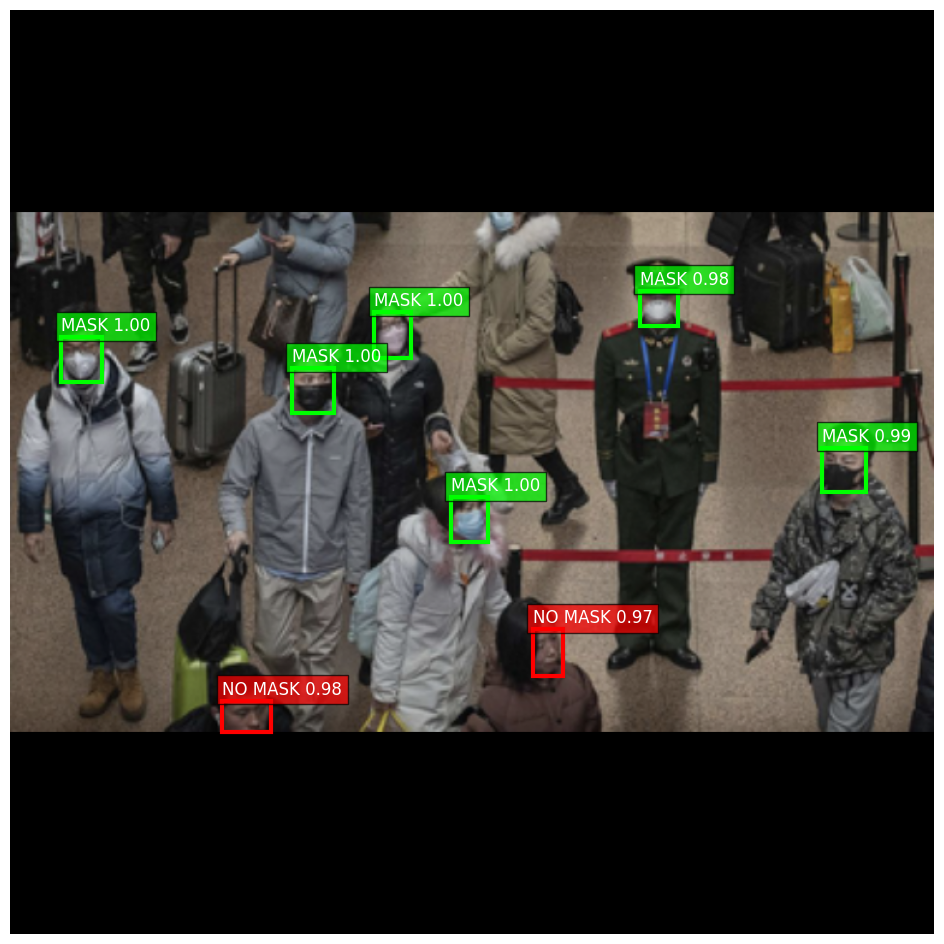

In [ ]:
# FINAL VISUALIZATION
import matplotlib.patches as patches

CLASS_NAMES = {
    1: "MASK",
    2: "NO MASK"
}

COLORS = {
    1: "lime",
    2: "red"
}

images, targets = next(iter(val_loader))

image = images[1].to(device)

model.eval()

with torch.no_grad():

    prediction = model([image])[0]

boxes = prediction["boxes"].cpu().numpy()
scores = prediction["scores"].cpu().numpy()
labels = prediction["labels"].cpu().numpy()

img = image.permute(1,2,0).cpu().numpy()

fig, ax = plt.subplots(1, figsize=(12,12))

ax.imshow(img)

for box, score, label in zip(boxes, scores, labels):

    if score < 0.5:
        continue

    x1, y1, x2, y2 = box

    rect = patches.Rectangle(
        (x1,y1),
        x2-x1,
        y2-y1,
        linewidth=3,
        edgecolor=COLORS[label],
        facecolor='none'
    )

    ax.add_patch(rect)

    ax.text(
        x1,
        y1-5,
        f"{CLASS_NAMES[label]} {score:.2f}",
        color="white",
        fontsize=12,
        bbox=dict(
            facecolor=COLORS[label],
            alpha=0.7
        )
    )

plt.axis("off")

plt.show()

In [ ]:
# IoU ANALYSIS
# здесь считаем средний IoU модели на validation.

import numpy as np

def compute_iou(box1, box2):

    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])

    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter = max(0, x2 - x1) * max(0, y2 - y1)

    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])

    union = area1 + area2 - inter + 1e-6

    return inter / union


ious = []

model.eval()

with torch.no_grad():

    for images, targets in val_loader:

        images = [img.to(device) for img in images]

        outputs = model(images)

        for i in range(len(images)):

            pred_boxes = outputs[i]["boxes"].cpu()
            pred_scores = outputs[i]["scores"].cpu()

            gt_boxes = targets[i]["boxes"]

            # confidence filtering
            keep = pred_scores > 0.5

            pred_boxes = pred_boxes[keep]

            for pb in pred_boxes:

                best_iou = 0

                for gb in gt_boxes:

                    iou = compute_iou(pb, gb)

                    if iou > best_iou:
                        best_iou = iou

                ious.append(best_iou)

mean_iou = np.mean(ious)

print("Mean IoU:", round(mean_iou, 4))

Mean IoU: 0.7241


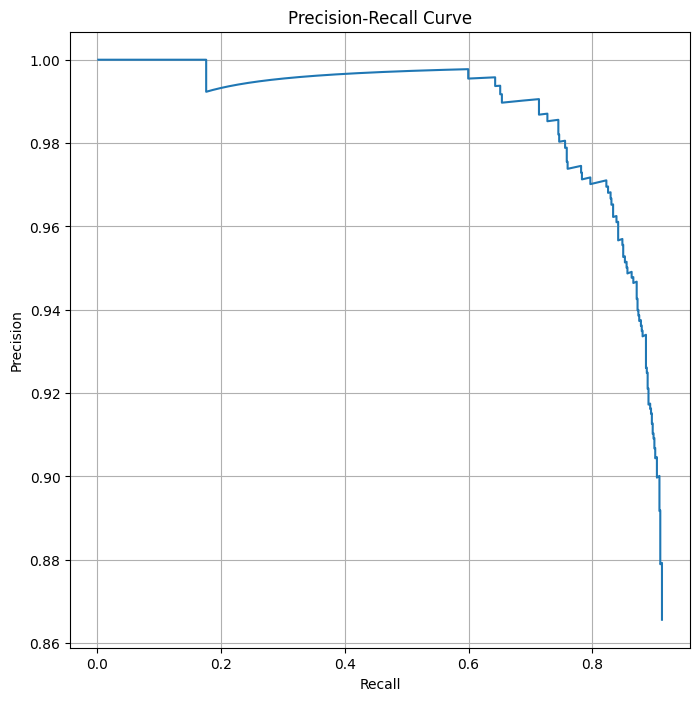

In [ ]:
# PR CURVE

import numpy as np
import matplotlib.pyplot as plt

model.eval()

all_scores = []
all_matches = []

total_gt = 0

iou_threshold = 0.5

with torch.no_grad():

    for images, targets in val_loader:

        images = [img.to(device) for img in images]

        outputs = model(images)

        for i in range(len(images)):

            pred_boxes = outputs[i]["boxes"].cpu()
            pred_scores = outputs[i]["scores"].cpu()
            pred_labels = outputs[i]["labels"].cpu()

            gt_boxes = targets[i]["boxes"].cpu()
            gt_labels = targets[i]["labels"].cpu()

            total_gt += len(gt_boxes)

            # SORT BY CONFIDENCE

            sorted_idx = pred_scores.argsort(descending=True)

            pred_boxes = pred_boxes[sorted_idx]
            pred_scores = pred_scores[sorted_idx]
            pred_labels = pred_labels[sorted_idx]

            matched_gt = set()

            for box, score, label in zip(
                pred_boxes,
                pred_scores,
                pred_labels
            ):

                best_iou = 0
                best_gt_idx = -1

                for j, gt_box in enumerate(gt_boxes):

                    if j in matched_gt:
                        continue

                    # CLASS CHECK

                    if label != gt_labels[j]:
                        continue

                    # IoU

                    x1 = max(box[0], gt_box[0])
                    y1 = max(box[1], gt_box[1])

                    x2 = min(box[2], gt_box[2])
                    y2 = min(box[3], gt_box[3])

                    inter = max(0, x2 - x1) * max(0, y2 - y1)

                    area_pred = (
                        (box[2] - box[0]) *
                        (box[3] - box[1])
                    )

                    area_gt = (
                        (gt_box[2] - gt_box[0]) *
                        (gt_box[3] - gt_box[1])
                    )

                    union = area_pred + area_gt - inter

                    iou = inter / (union + 1e-6)

                    if iou > best_iou:

                        best_iou = iou
                        best_gt_idx = j

                # TRUE POSITIVE / FALSE POSITIVE

                if best_iou >= iou_threshold:

                    all_matches.append(1)

                    matched_gt.add(best_gt_idx)

                else:

                    all_matches.append(0)

                all_scores.append(score.item())

# NUMPY

all_scores = np.array(all_scores)
all_matches = np.array(all_matches)

# GLOBAL SORT

sorted_idx = np.argsort(-all_scores)

all_matches = all_matches[sorted_idx]

# CUMULATIVE TP / FP

tp = np.cumsum(all_matches)

fp = np.cumsum(1 - all_matches)

precision = tp / (tp + fp + 1e-6)

recall = tp / (total_gt + 1e-6)

# PLOT

plt.figure(figsize=(8,8))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.grid(True)

plt.show()

# Faster R-CNN Training Analysis

Во время обучения модели Faster R-CNN использовалась ранняя остановка обучения (Early Stopping) при достижении целевой метрики:

- **Target mAP50 = 0.85**

Модель успешно достигла данного значения:

- **mAP50 = 0.8570**
- **Mean IoU = 0.7174**

После достижения целевой метрики обучение было остановлено автоматически.

Однако дальнейшие эксперименты без ранней остановки показали, что модель продолжила улучшаться и достигла более высокого качества:

- **Best mAP50 = 0.8880**
- **Mean IoU = 0.7241**

Это показывает, что ранняя остановка помогла избежать возможного прерывания обучения из-за ограничений GPU в Google Colab, однако при этом модель не успела полностью раскрыть свой потенциал.

Таким образом:

- Early Stopping полезен для экономии времени и защиты от внезапного отключения GPU;
- но для получения максимально возможного качества модели лучше позволить обучению продолжаться дольше, если вычислительные ресурсы это позволяют.